# Nordea Case Study: IBM HR Analytics Employee Attrition
This notebook focuses only on exploratory data analysis (EDA).
No modeling or prediction is performed here — the goal is to understand patterns, relationships, and potential drivers of employee attrition.



## 1. Setup and Data Loading

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")

# Load the dataset
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

# Display first few rows
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [12]:
# Check for missing values and data types
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

## 2. Data Cleaning

In this step, we prepare the dataset for analysis by converting key variables into numerical format and removing non-informative features.

- The target variable **Attrition** is converted from categorical values (Yes/No) to numerical (1/0).
- The **OverTime** feature is also converted to binary form (Yes = 1, No = 0).
- The column **Over18** is removed since it contains the same value for all observations and does not provide useful information.
- Additional categorical encoding (e.g., one-hot encoding) can be applied if needed for further analysis.

This step ensures the dataset is consistent and ready for exploration.

In [13]:
# convert to numeric data
df['Attrition'] = df['Attrition'].map({'Yes':1, 'No':0})
df.OverTime = df.OverTime.map({'No':0,'Yes':1})

# drop Over18 since it is same value anywasy
df = df.drop(columns=['Over18'])

# hot encode the rest
df = pd.get_dummies(df, dtype=int)

df['incomeBin'] = pd.cut(df['MonthlyIncome'], bins=10)
df['ageBin'] = pd.cut(df['Age'], bins=6)

## 3. Exploratory Data Analysis (EDA)

The goal of this section is to understand patterns and relationships in the data before modeling.

We begin by analyzing the target variable (Attrition) to understand class distribution, followed by correlation analysis to capture overall relationships between features.

The analysis is then structured around four main driver categories:

- Workload  
- Seniority & Compensation  
- Role Structure  
- Life Stage  

This approach ensures consistency between EDA, feature engineering, and the final decision system.

### 3.1 Attrition Distribution

We begin by analyzing the distribution of the target variable (Attrition) to understand the proportion of employees who leave versus stay.

This provides a baseline view of the problem and highlights any class imbalance in the dataset.

In [5]:
df['Attrition'].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

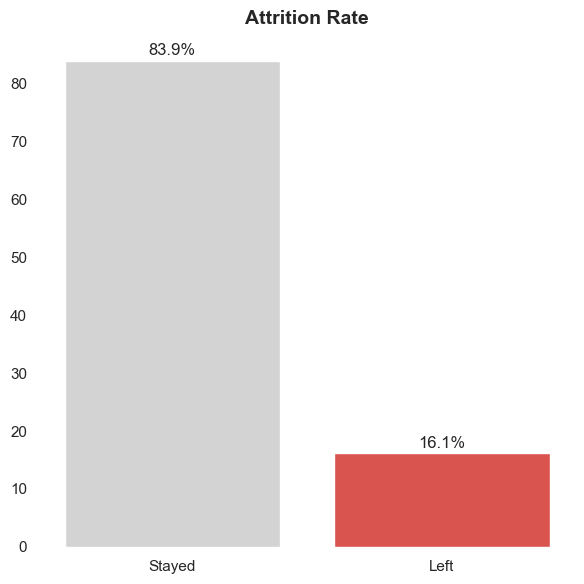

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# compute counts
counts = df['Attrition'].value_counts().sort_index()

labels = ['Stayed', 'Left']
values = counts.values

# convert to percentages
total = values.sum()
percentages = (values / total) * 100

plt.figure(figsize=(6,6))

# colors (highlight "Left")
colors = ['lightgray', '#D9534F']

bars = plt.bar(labels, percentages, color=colors)

# remove clutter
plt.grid(False)
plt.box(False)

# add percentage labels
for i, v in enumerate(percentages):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center', fontsize=12)

plt.title('Attrition Rate', fontsize=14, weight='bold')
plt.ylabel('')
plt.xlabel('')

plt.ylim(0, max(percentages) + 5)

plt.tight_layout()
plt.show()

### 3.2 Correlation Analysis

Next, we examine the correlation between numerical features and attrition.

This helps identify:
- Key variables associated with attrition  
- Direction of relationships (positive or negative)  
- Potential signals for feature engineering  

This step provides a high-level overview before diving into driver-specific analysis.

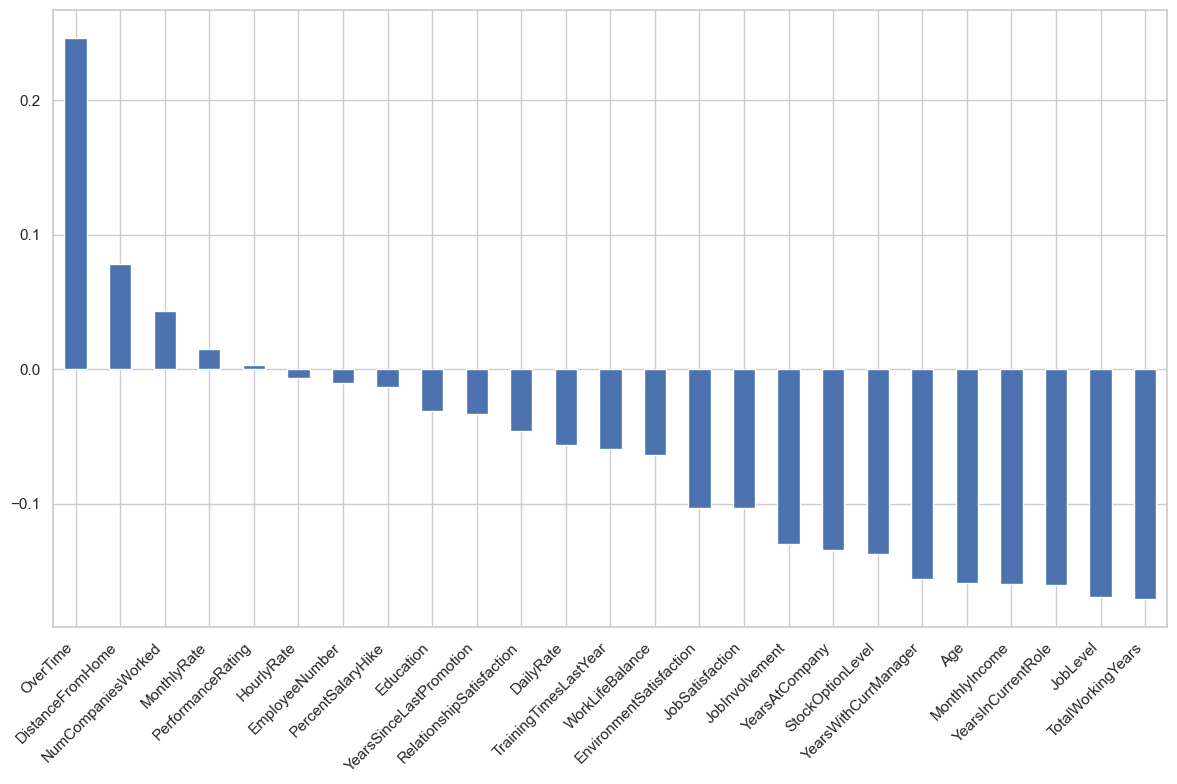

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

corr = df.corr(numeric_only=True)['Attrition'].sort_values(ascending=False)[1:].dropna()
corr.plot(kind='bar')

plt.xticks(rotation=45, ha='right')  
plt.tight_layout()
plt.show()

## 3.3 Workload Drivers

This section explores how workload and engagement-related factors influence employee attrition.

Key variables:
- OverTime  
- WorkLifeBalance  
- JobInvolvement  

These features help capture both:
- High workload (burnout risk)  
- Low engagement (underutilization)

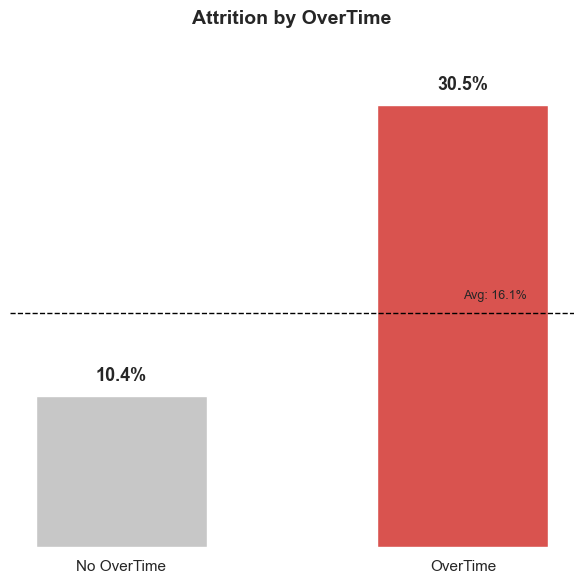

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# compute attrition rate by OverTime
attrition_rate = (
    df.groupby('OverTime')['Attrition']
    .apply(lambda x: (x == 1).mean() * 100)
)


attrition_rate.index = ['No OverTime', 'OverTime']

# colors 
colors = ['#C7C7C7', '#D9534F']  # soft gray, muted red

plt.figure(figsize=(6,6))

bars = plt.bar(attrition_rate.index, attrition_rate.values, color=colors, width=0.5)

# remove clutter
plt.grid(False)
plt.box(False)

# remove y-axis ticks
plt.yticks([])

# add labels on bars
for i, v in enumerate(attrition_rate.values):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center', fontsize=13, weight='bold')

# title
plt.title('Attrition by OverTime', fontsize=14, weight='bold')

plt.ylim(0, max(attrition_rate.values) + 5)

# baseline
baseline = (df['Attrition'] == 1).mean() * 100

plt.axhline(y=baseline, linestyle='--', color='black', linewidth=1)

# place text near right bar
plt.text(1, baseline + 1, f'Avg: {baseline:.1f}%', fontsize=9)

plt.tight_layout()
plt.show()


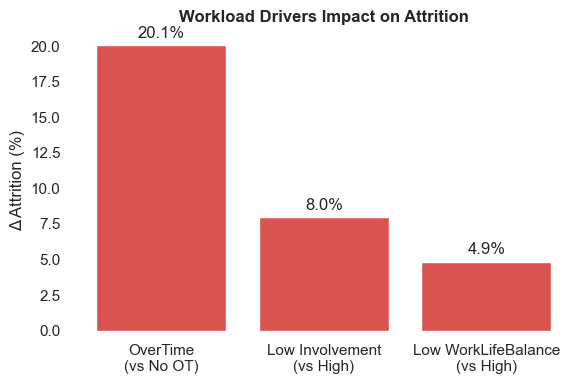

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

results = {}

# 1. OverTime
p_yes = df[df['OverTime']==1]['Attrition'].eq(1).mean()
p_no  = df[df['OverTime']==0]['Attrition'].eq(1).mean()
results['OverTime\n(vs No OT)'] = (p_yes - p_no) * 100

# 2. WorkLifeBalance
low = df[df['WorkLifeBalance'] <= 2]['Attrition'].eq(1).mean()
high = df[df['WorkLifeBalance'] >= 3]['Attrition'].eq(1).mean()
results['Low WorkLifeBalance\n(vs High)'] = (low - high) * 100

# 3. JobInvolvement
low = df[df['JobInvolvement'] <= 2]['Attrition'].eq(1).mean()
high = df[df['JobInvolvement'] >= 3]['Attrition'].eq(1).mean()
results['Low Involvement\n(vs High)'] = (low - high) * 100

impact = pd.Series(results).sort_values(ascending=False)

# plot
plt.figure(figsize=(6,4))
bars = plt.bar(impact.index, impact.values, color='#D9534F')

plt.title('Workload Drivers Impact on Attrition', weight='bold')
plt.ylabel('Δ Attrition (%)')

# labels
for i, v in enumerate(impact.values):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center')

plt.grid(False)
plt.box(False)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 3.4 Seniority & Compensation Drivers

This section examines how career progression, tenure, and compensation influence employee attrition.

Key variables:
- MonthlyIncome  
- JobLevel  
- YearsAtCompany  
- YearsSinceLastPromotion  

These features help identify:
- Compensation misalignment  
- Lack of career progression  
- Employee stability

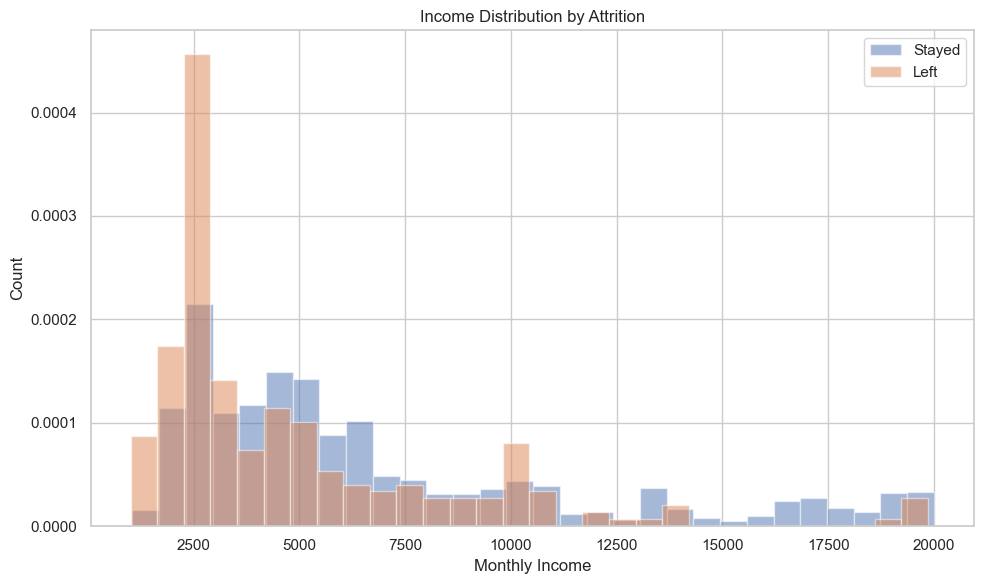

In [245]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(df[df['Attrition']==0]['MonthlyIncome'],density=True, bins=30, alpha=0.5, label='Stayed')
plt.hist(df[df['Attrition']==1]['MonthlyIncome'],density=True, bins=30, alpha=0.5, label='Left')

plt.title('Income Distribution by Attrition')
plt.xlabel('Monthly Income')
plt.ylabel('Count')
plt.legend()

plt.tight_layout()
plt.show()

/var/folders/44/bgk7f8f14ts6lstf71mlfw7w0000gn/T/ipykernel_37341/4244832595.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = df.groupby('incomeBin')['Attrition'].mean()


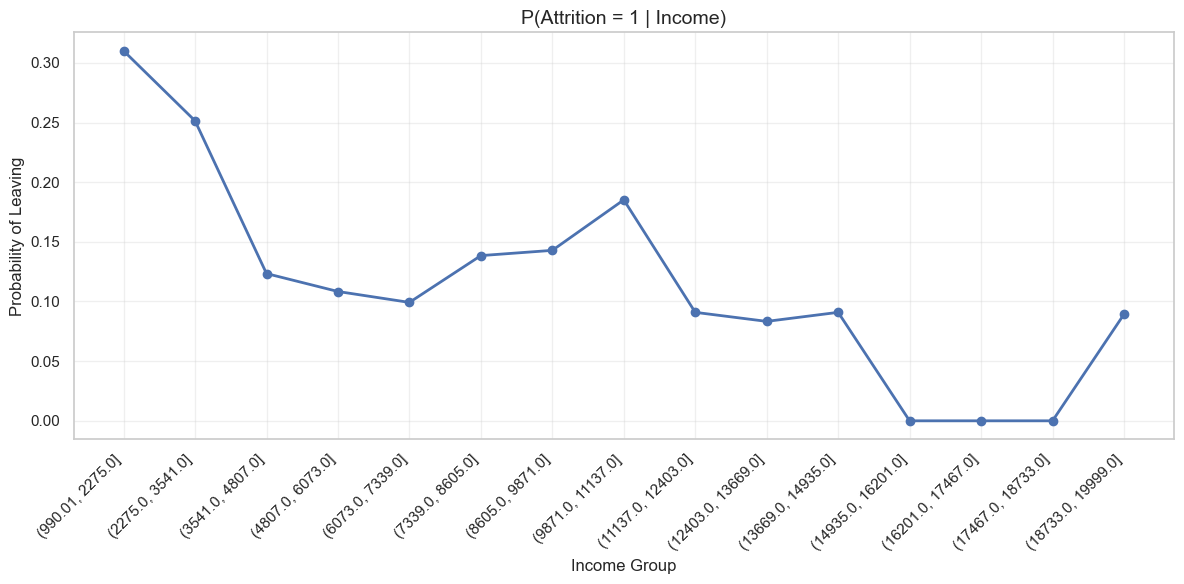

In [ ]:
import matplotlib.pyplot as plt

# Create bins
df['incomeBin'] = pd.cut(df['MonthlyIncome'], bins=15)

# Compute probability
result = df.groupby('incomeBin')['Attrition'].mean()

# Plot
plt.figure(figsize=(12,6))

plt.plot(result.index.astype(str), result.values, marker='o', linewidth=2)

# Titles & labels
plt.title('P(Attrition = 1 | Income)', fontsize=14)
plt.xlabel('Income Group', fontsize=12)
plt.ylabel('Probability of Leaving', fontsize=12)

# Improve readability
plt.xticks(rotation=45, ha='right')
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

/var/folders/44/bgk7f8f14ts6lstf71mlfw7w0000gn/T/ipykernel_46317/520143196.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('IncomeGroup')['Attrition']


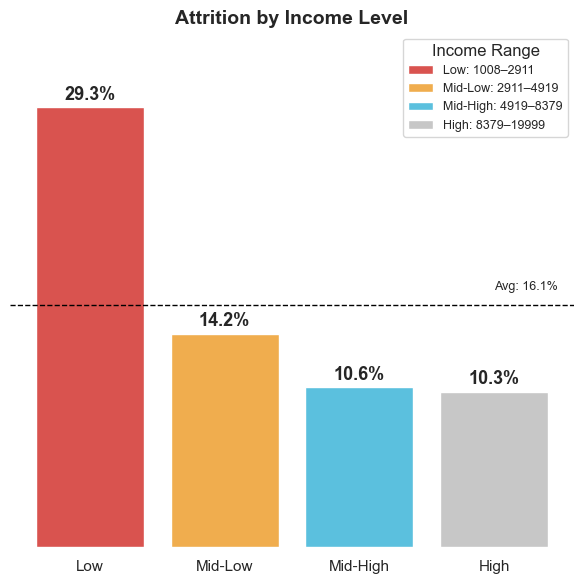

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# create bins
bins = pd.qcut(df['MonthlyIncome'], q=4)

# create labels
labels = ['Low', 'Mid-Low', 'Mid-High', 'High']
df['IncomeGroup'] = pd.qcut(df['MonthlyIncome'], q=4, labels=labels)

# compute attrition rate
attrition_rate = (
    df.groupby('IncomeGroup')['Attrition']
    .apply(lambda x: (x == 1).mean() * 100)
)

# extract ranges for legend
intervals = bins.cat.categories
legend_labels = [
    f"{labels[i]}: {int(interval.left)}–{int(interval.right)}"
    for i, interval in enumerate(intervals)
]

# colors
colors = ['#D9534F', '#F0AD4E', '#5BC0DE', '#C7C7C7']

# plot
plt.figure(figsize=(6,6))
bars = plt.bar(attrition_rate.index, attrition_rate.values, color=colors)

# remove clutter
plt.grid(False)
plt.box(False)
plt.yticks([])

# add values
for i, v in enumerate(attrition_rate.values):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontsize=13, weight='bold')

# legend
legend_elements = [
    Patch(facecolor=colors[i], label=legend_labels[i])
    for i in range(4)
]
plt.legend(handles=legend_elements, title="Income Range", fontsize=9)

# title
plt.title('Attrition by Income Level', fontsize=14, weight='bold')

plt.ylim(0, max(attrition_rate.values) + 5)

baseline = (df['Attrition'] == 1).mean() * 100

plt.axhline(y=baseline, linestyle='--', color='black', linewidth=1)

plt.text(3, baseline + 1, f'Avg: {baseline:.1f}%', fontsize=9)
plt.tight_layout()
plt.show()

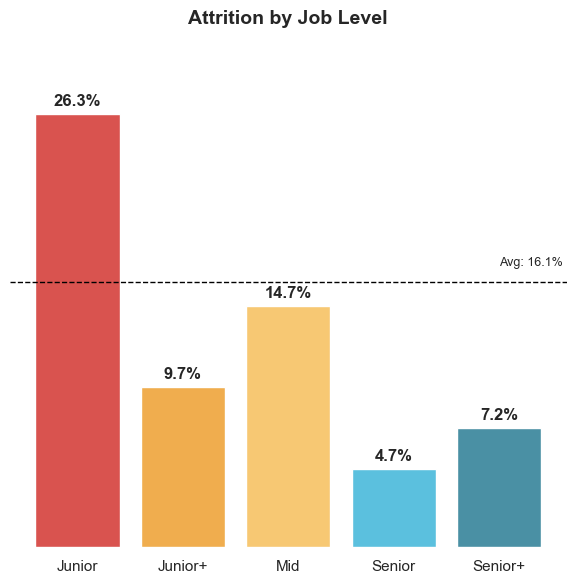

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# compute attrition
attrition_rate = (
    df.groupby('JobLevel')['Attrition']
    .apply(lambda x: (x == 1).mean() * 100)
    .sort_index()
)

# map labels
level_map = {
    1: 'Junior',
    2: 'Junior+',
    3: 'Mid',
    4: 'Senior',
    5: 'Senior+'
}
labels = [level_map[i] for i in attrition_rate.index]

# colors (gradient: risky → safe)
colors = ['#D9534F', '#F0AD4E', '#F7C873', '#5BC0DE', '#4A90A4']

# plot
plt.figure(figsize=(6,6))
bars = plt.bar(labels, attrition_rate.values, color=colors)

# clean
plt.grid(False)
plt.box(False)
plt.yticks([])

# values
for i, v in enumerate(attrition_rate.values):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontsize=12, weight='bold')

# baseline
baseline = (df['Attrition'] == 1).mean() * 100
plt.axhline(y=baseline, linestyle='--', color='black', linewidth=1)
plt.text(len(labels)-1, baseline + 1, f'Avg: {baseline:.1f}%', fontsize=9)

# title
plt.title('Attrition by Job Level', fontsize=14, weight='bold')

plt.ylim(0, max(attrition_rate.values) + 5)

plt.tight_layout()
plt.show()

/var/folders/44/bgk7f8f14ts6lstf71mlfw7w0000gn/T/ipykernel_46317/86613887.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_subset.groupby(['IncomeGroup', 'JobLevelLabel'])['Attrition']


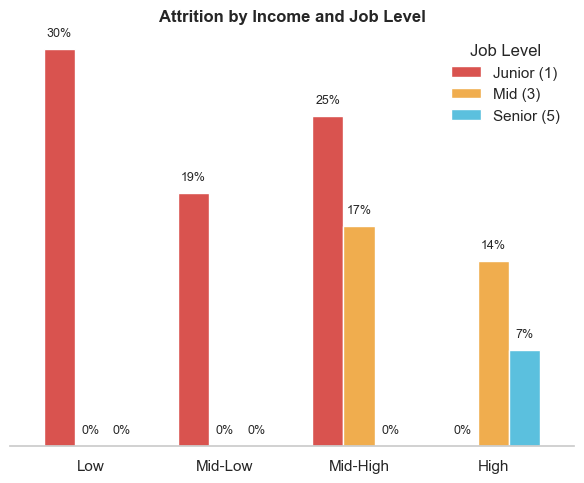

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Income groups
df['IncomeGroup'] = pd.qcut(
    df['MonthlyIncome'],
    q=4,
    labels=['Low', 'Mid-Low', 'Mid-High', 'High']
)

#  Select levels
levels = [1, 3, 5]
df_subset = df[df['JobLevel'].isin(levels)].copy()

#  Map labels
level_map = {
    1: 'Junior (1)',
    3: 'Mid (3)',
    5: 'Senior (5)'
}
df_subset['JobLevelLabel'] = df_subset['JobLevel'].map(level_map)

#  Compute attrition %
result = (
    df_subset.groupby(['IncomeGroup', 'JobLevelLabel'])['Attrition']
    .apply(lambda x: (x == 1).mean() * 100)
    .reset_index()
)

#  Pivot
pivot = result.pivot(
    index='IncomeGroup',
    columns='JobLevelLabel',
    values='Attrition'
)

# Ensure consistent column order
pivot = pivot[['Junior (1)', 'Mid (3)', 'Senior (5)']]

#  Plot
fig, ax = plt.subplots(figsize=(6,5))

colors = ['#D9534F', '#F0AD4E', '#5BC0DE']
pivot.plot(kind='bar', ax=ax, color=colors, width=0.7)

#  Clean style
ax.grid(False)
ax.spines[['top','right','left']].set_visible(False)
ax.set_yticks([])
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticklabels(pivot.index, rotation=0)

#  Add value labels
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if not pd.isna(height):
            ax.text(
                bar.get_x() + bar.get_width()/2,
                height + 1,
                f"{height:.0f}%",
                ha='center',
                fontsize=9
            )

#  Legend
ax.legend(title='Job Level', frameon=False)

#  Title
ax.set_title('Attrition by Income and Job Level', weight='bold')

plt.tight_layout()
plt.show()

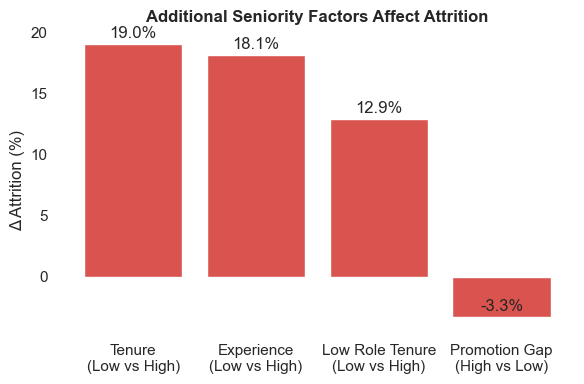

In [ ]:
results = {}

# Experience
low = df[df['TotalWorkingYears'] <= 5]['Attrition'].eq(1).mean()
high = df[df['TotalWorkingYears'] >= 10]['Attrition'].eq(1).mean()
results['Experience\n(Low vs High)'] = (low - high) * 100

# Years at company
low = df[df['YearsAtCompany'] <= 2]['Attrition'].eq(1).mean()
high = df[df['YearsAtCompany'] >= 5]['Attrition'].eq(1).mean()
results['Tenure\n(Low vs High)'] = (low - high) * 100

# Years in current role
low = df[df['YearsInCurrentRole'] <= 2]['Attrition'].eq(1).mean()
high = df[df['YearsInCurrentRole'] >= 5]['Attrition'].eq(1).mean()
results['Low Role Tenure\n(Low vs High)'] = (low - high) * 100

# Promotion gap
high_gap = df[df['YearsSinceLastPromotion'] >= 3]['Attrition'].eq(1).mean()
low_gap = df[df['YearsSinceLastPromotion'] <= 1]['Attrition'].eq(1).mean()
results['Promotion Gap\n(High vs Low)'] = (high_gap - low_gap) * 100

impact = pd.Series(results).sort_values(ascending=False)

# plot
plt.figure(figsize=(6,4))
bars = plt.bar(impact.index, impact.values, color='#D9534F')

plt.title('Additional Seniority Factors Affect Attrition', weight='bold')
plt.ylabel('Δ Attrition (%)')

for i, v in enumerate(impact.values):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center')

plt.grid(False)
plt.box(False)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

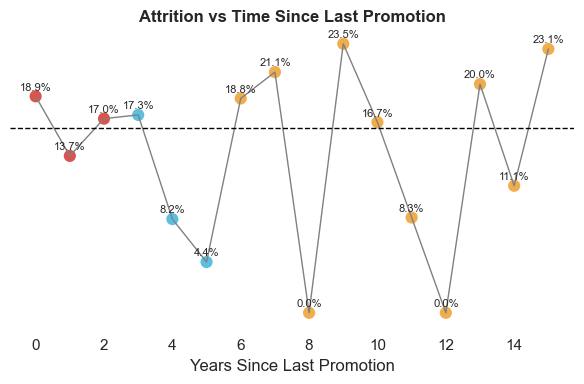

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# compute
promo = (
    df.groupby('YearsSinceLastPromotion')['Attrition']
    .apply(lambda x: (x == 1).mean() * 100)
)

x = promo.index
y = promo.values

# define colors by group
colors = []
for val in x:
    if val <= 2:
        colors.append('#D9534F')   # red (recent)
    elif val <= 5:
        colors.append('#5BC0DE')   # blue (stable)
    else:
        colors.append('#F0AD4E')   # orange (long gap)

plt.figure(figsize=(6,4))

# line
plt.plot(x, y, color='gray', linewidth=1)

# points with colors
plt.scatter(x, y, c=colors, s=60)

# clean
plt.grid(False)
plt.box(False)
plt.yticks([])

# labels
for xi, yi in zip(x, y):
    plt.text(xi, yi + 0.5, f"{yi:.1f}%", ha='center', fontsize=8)

# baseline
baseline = (df['Attrition'] == 1).mean() * 100
plt.axhline(y=baseline, linestyle='--', color='black', linewidth=1)

# title
plt.title('Attrition vs Time Since Last Promotion', weight='bold')
plt.xlabel('Years Since Last Promotion')

plt.tight_layout()
plt.show()

/var/folders/44/bgk7f8f14ts6lstf71mlfw7w0000gn/T/ipykernel_46889/4047201613.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('PromoGroup')['Attrition']


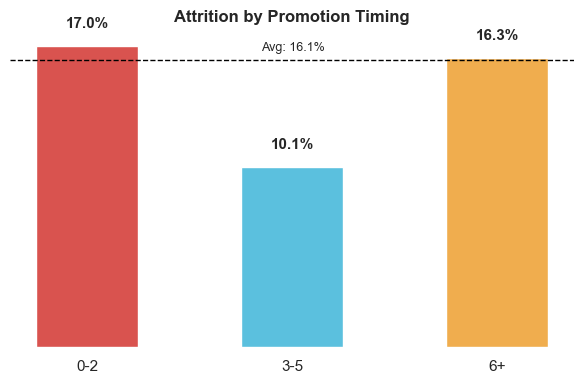

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# bins
df['PromoGroup'] = pd.cut(
    df['YearsSinceLastPromotion'],
    bins=[-1, 2, 5, 100],
    labels=['0-2', '3-5', '6+']
)

# compute
promo = (
    df.groupby('PromoGroup')['Attrition']
    .apply(lambda x: (x == 1).mean() * 100)
)

# colors 
colors = ['#D9534F', '#5BC0DE', '#F0AD4E']  # red, blue, orange

plt.figure(figsize=(6,4))

bars = plt.bar(promo.index, promo.values, color=colors, width=0.5)

# clean
plt.grid(False)
plt.box(False)
plt.yticks([])

# labels
for i, v in enumerate(promo.values):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center', fontsize=11, weight='bold')

# baseline
baseline = (df['Attrition'] == 1).mean() * 100
plt.axhline(y=baseline, linestyle='--', color='black', linewidth=1)
plt.text(0.85, baseline + 0.5, f'Avg: {baseline:.1f}%', fontsize=9)

# title
plt.title('Attrition by Promotion Timing', weight='bold')

plt.tight_layout()
plt.show()

/var/folders/44/bgk7f8f14ts6lstf71mlfw7w0000gn/T/ipykernel_46889/1541403622.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('ExpGroup')['Attrition']


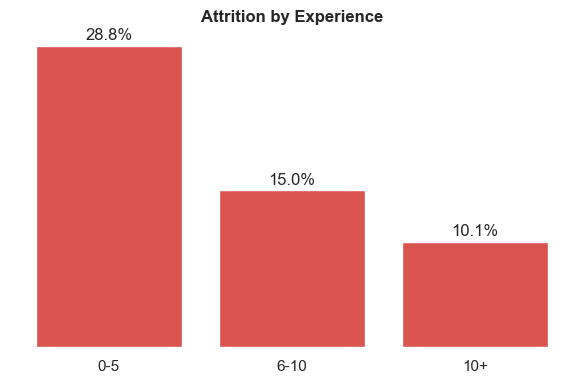

In [ ]:
df['ExpGroup'] = pd.cut(
    df['TotalWorkingYears'],
    bins=[-1, 5, 10, 40],
    labels=['0-5', '6-10', '10+']
)

exp = (
    df.groupby('ExpGroup')['Attrition']
    .apply(lambda x: (x == 1).mean() * 100)
)

plt.figure(figsize=(6,4))
plt.bar(exp.index, exp.values, color='#D9534F')

plt.grid(False); plt.box(False); plt.yticks([])

for i, v in enumerate(exp.values):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center')

plt.title('Attrition by Experience', weight='bold')
plt.tight_layout()
plt.show()

/var/folders/44/bgk7f8f14ts6lstf71mlfw7w0000gn/T/ipykernel_46889/2275784962.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('TenureGroup')['Attrition']


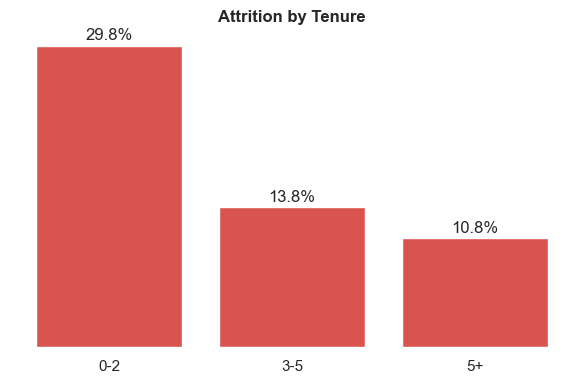

In [ ]:
df['TenureGroup'] = pd.cut(
    df['YearsAtCompany'],
    bins=[-1, 2, 5, 40],
    labels=['0-2', '3-5', '5+']
)

tenure = (
    df.groupby('TenureGroup')['Attrition']
    .apply(lambda x: (x == 1).mean() * 100)
)

plt.figure(figsize=(6,4))
plt.bar(tenure.index, tenure.values, color='#D9534F')

plt.grid(False); plt.box(False); plt.yticks([])

for i, v in enumerate(tenure.values):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center')

plt.title('Attrition by Tenure', weight='bold')
plt.tight_layout()
plt.show()

/var/folders/44/bgk7f8f14ts6lstf71mlfw7w0000gn/T/ipykernel_46889/3770046526.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('RoleGroup')['Attrition']


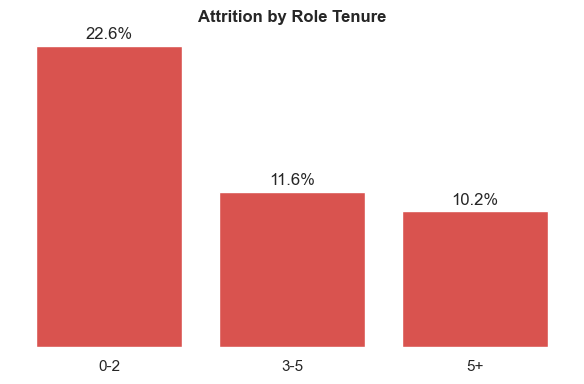

In [ ]:
df['RoleGroup'] = pd.cut(
    df['YearsInCurrentRole'],
    bins=[-1, 2, 5, 40],
    labels=['0-2', '3-5', '5+']
)

role = (
    df.groupby('RoleGroup')['Attrition']
    .apply(lambda x: (x == 1).mean() * 100)
)

plt.figure(figsize=(6,4))
plt.bar(role.index, role.values, color='#D9534F')

plt.grid(False); plt.box(False); plt.yticks([])

for i, v in enumerate(role.values):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center')

plt.title('Attrition by Role Tenure', weight='bold')
plt.tight_layout()
plt.show()

## 3.5 Role Structure Drivers

This section examines how job structure and work conditions influence employee attrition.

Key variables:
- BusinessTravel  
- JobRole  
- Department  

These features capture:
- Travel burden  
- Role-related demands  
- Organizational structure effects

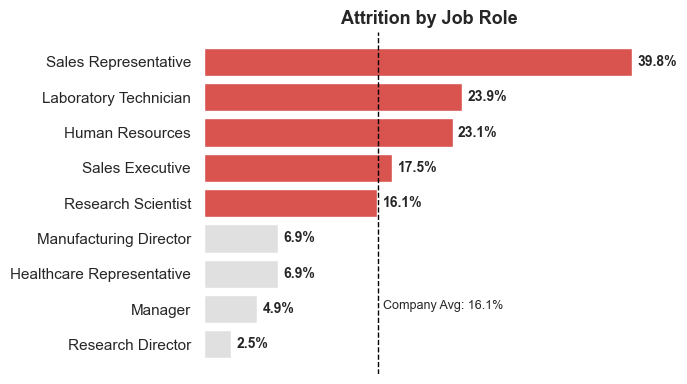

In [ ]:


import matplotlib.pyplot as plt

# compute %
role = (
    df.groupby('JobRole')['Attrition']
    .apply(lambda x: (x == 1).mean() * 100)
    .sort_values(ascending=True)
)

baseline = (df['Attrition'] == 1).mean() * 100

# color by above/below avg
colors = [
    '#D9534F' if v >= baseline-0.5 else '#E0E0E0'
    for v in role.values
]

plt.figure(figsize=(7,4))

bars = plt.barh(role.index, role.values, color=colors)

# clean
plt.grid(False)
plt.box(False)
plt.xticks([])

# labels
for i, v in enumerate(role.values):
    plt.text(v + 0.5, i, f"{v:.1f}%", va='center', fontsize=10, weight='bold')

# baseline
plt.axvline(x=baseline, linestyle='--', color='black', linewidth=1)
plt.text(baseline + 0.5, 1, f'Company Avg: {baseline:.1f}%', fontsize=9)

# title
plt.title('Attrition by Job Role', fontsize=13, weight='bold')

plt.tight_layout()
plt.show()

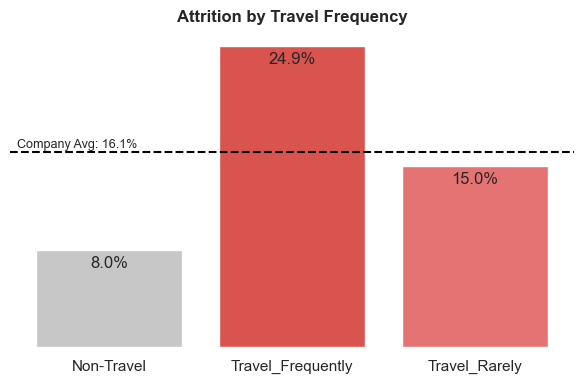

In [ ]:
travel = (
    df.groupby('BusinessTravel')['Attrition']
    .apply(lambda x: (x == 1).mean() * 100)
)

plt.figure(figsize=(6,4))

colors = ['#C7C7C7', '#D9534F', '#E57373']  # highlight travel

plt.bar(travel.index, travel.values, color=colors)

plt.grid(False)
plt.box(False)
plt.yticks([])

for i, v in enumerate(travel.values):
    plt.text(i, v -1.5, f"{v:.1f}%", ha='center')

baseline = (df['Attrition'] == 1).mean() * 100
plt.axhline(y=baseline, linestyle='--', color='black')
plt.text(-0.5, baseline+0.3, f'Company Avg: {baseline:.1f}%', fontsize=9)

plt.title('Attrition by Travel Frequency', weight='bold')

plt.tight_layout()
plt.show()

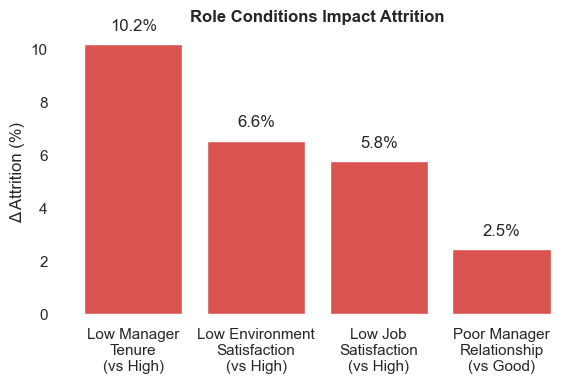

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

results = {}

# 1. Travel (Frequent vs None)
# high = df[df['BusinessTravel'] == 'Travel_Frequently']['Attrition'].eq(1).mean()
# low  = df[df['BusinessTravel'] == 'Non-Travel']['Attrition'].eq(1).mean()
# results['Travel\n(Frequent vs None)'] = (high - low) * 100

# 2. Job Satisfaction (Low vs High)
low = df[df['JobSatisfaction'] <= 2]['Attrition'].eq(1).mean()
high = df[df['JobSatisfaction'] >= 3]['Attrition'].eq(1).mean()
results['Low Job\nSatisfaction\n(vs High)'] = (low - high) * 100

# 3. Environment Satisfaction
low = df[df['EnvironmentSatisfaction'] <= 2]['Attrition'].eq(1).mean()
high = df[df['EnvironmentSatisfaction'] >= 3]['Attrition'].eq(1).mean()
results['Low Environment\nSatisfaction\n(vs High)'] = (low - high) * 100

# 4. Manager Tenure
low = df[df['YearsWithCurrManager'] <= 2]['Attrition'].eq(1).mean()
high = df[df['YearsWithCurrManager'] >= 5]['Attrition'].eq(1).mean()
results['Low Manager\nTenure\n(vs High)'] = (low - high) * 100

# 5. Manager Relationship (Low vs High)
low = df[df['RelationshipSatisfaction'] <= 2]['Attrition'].eq(1).mean()
high = df[df['RelationshipSatisfaction'] >= 3]['Attrition'].eq(1).mean()
results['Poor Manager\nRelationship\n(vs Good)'] = (low - high) * 100
impact = pd.Series(results).sort_values(ascending=False)

# plot
plt.figure(figsize=(6,4))
bars = plt.bar(impact.index, impact.values, color='#D9534F')

plt.title('Role Conditions Impact Attrition', weight='bold')
plt.ylabel('Δ Attrition (%)')

# labels
for i, v in enumerate(impact.values):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center')

plt.grid(False)
plt.box(False)

plt.tight_layout()
plt.show()

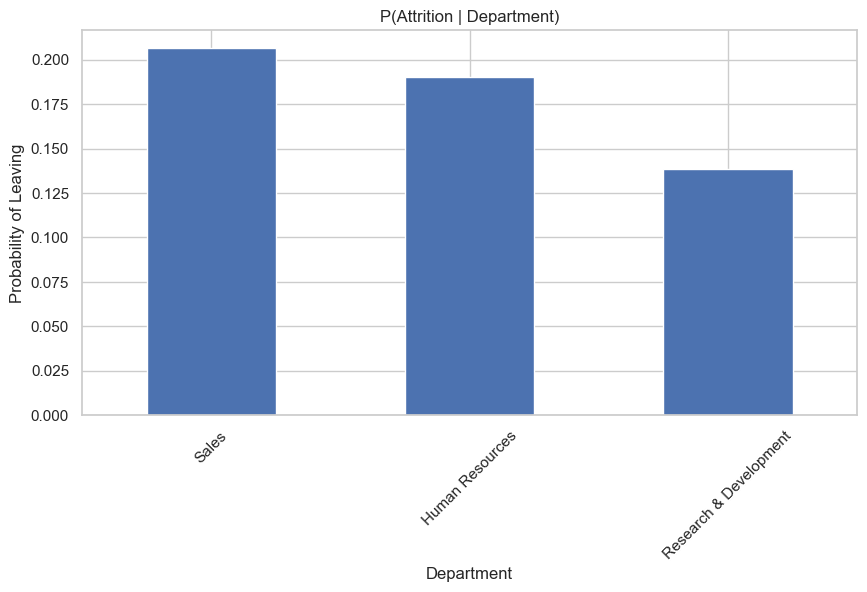

In [ ]:
cat_col = 'Department'

cat_df = df.groupby(cat_col)['Attrition'].mean().sort_values(ascending=False)

cat_df.plot(kind='bar', figsize=(10,5))
plt.title(f'P(Attrition | {cat_col})')
plt.ylabel('Probability of Leaving')
plt.xticks(rotation=45)
plt.show()

## 3.6 Life Stage Drivers

This section explores how personal and demographic factors influence employee attrition.

Key variables:
- Age  
- MaritalStatus  
- DistanceFromHome  

These features capture:
- Early career mobility  
- Personal constraints  
- Commuting burden

/var/folders/44/bgk7f8f14ts6lstf71mlfw7w0000gn/T/ipykernel_37341/3866281915.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = df.groupby('AgeBin')['Attrition'].mean()


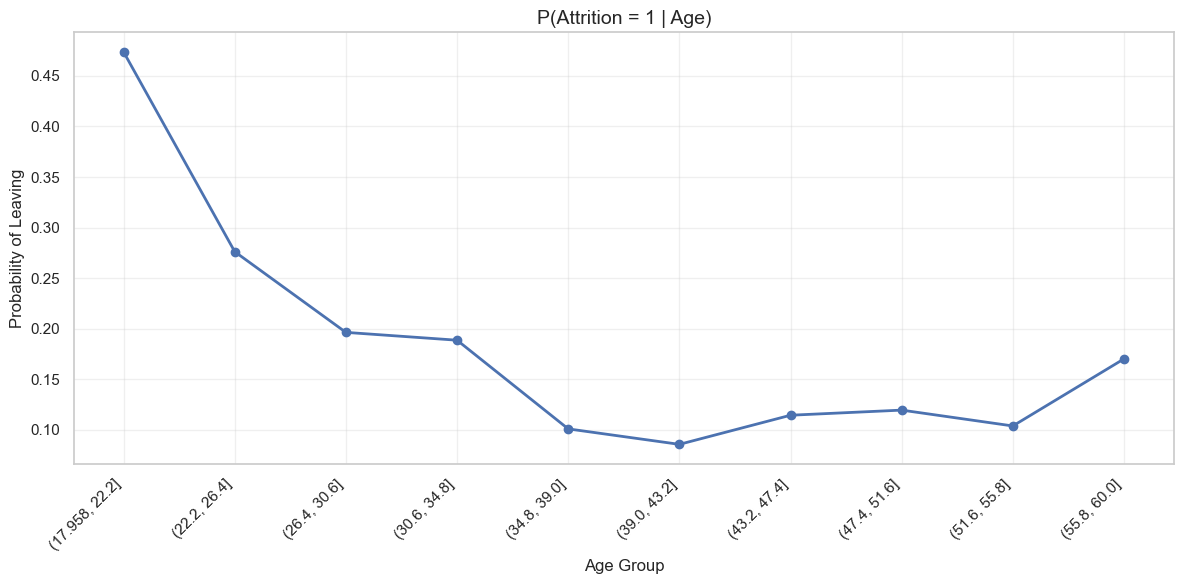

In [ ]:
import matplotlib.pyplot as plt

# Create bins
df['AgeBin'] = pd.cut(df['Age'], bins=10)

# Compute probability
result = df.groupby('AgeBin')['Attrition'].mean()

# Plot
plt.figure(figsize=(12,6))

plt.plot(result.index.astype(str), result.values, marker='o', linewidth=2)

# Titles & labels
plt.title('P(Attrition = 1 | Age)', fontsize=14)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Probability of Leaving', fontsize=12)

# Improve readability
plt.xticks(rotation=45, ha='right')
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

/var/folders/44/bgk7f8f14ts6lstf71mlfw7w0000gn/T/ipykernel_46889/3561454636.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('AgeGroup')['Attrition']


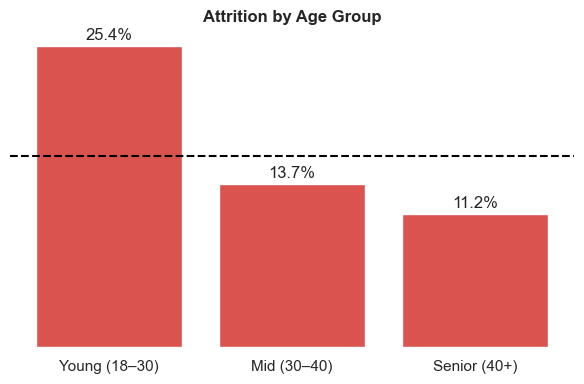

In [ ]:
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[18, 30, 40, 60],
    labels=['Young (18–30)', 'Mid (30–40)', 'Senior (40+)']
)

age = (
    df.groupby('AgeGroup')['Attrition']
    .apply(lambda x: (x == 1).mean() * 100)
)

plt.figure(figsize=(6,4))
plt.bar(age.index, age.values, color='#D9534F')

plt.grid(False)
plt.box(False)
plt.yticks([])

for i, v in enumerate(age.values):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center')

baseline = (df['Attrition'] == 1).mean() * 100
plt.axhline(y=baseline, linestyle='--', color='black')

plt.title('Attrition by Age Group', weight='bold')

plt.tight_layout()
plt.show()

/var/folders/44/bgk7f8f14ts6lstf71mlfw7w0000gn/T/ipykernel_46889/1940115886.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age = df.groupby('AgeGroup')['Attrition'].apply(lambda x: (x==1).mean()*100)
/var/folders/44/bgk7f8f14ts6lstf71mlfw7w0000gn/T/ipykernel_46889/1940115886.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dist = df.groupby('DistanceGroup')['Attrition'].apply(lambda x: (x==1).mean()*100)
/var/folders/44/bgk7f8f14ts6lstf71mlfw7w0000gn/T/ipykernel_46889/1940115886.py:70: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of panda

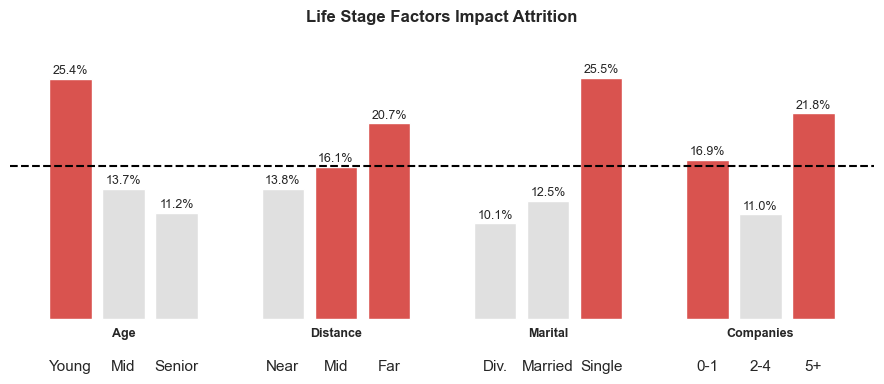

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

labels = []
values = []
positions = []
section_centers = {}

x = 0

# --- Age ---
df['AgeGroup'] = pd.cut(df['Age'], bins=[18,30,40,60],
                        labels=['Young', 'Mid', 'Senior'])

age = df.groupby('AgeGroup')['Attrition'].apply(lambda x: (x==1).mean()*100)

start = x
for k, v in age.items():
    labels.append(k)
    values.append(v)
    positions.append(x)
    x += 1
end = x-1
section_centers['Age'] = (start + end) / 2

x += 1  # spacer

# --- Distance ---
df['DistanceGroup'] = pd.cut(df['DistanceFromHome'],
                             bins=[-1,5,15,100],
                             labels=['Near', 'Mid', 'Far'])

dist = df.groupby('DistanceGroup')['Attrition'].apply(lambda x: (x==1).mean()*100)

start = x
for k, v in dist.items():
    labels.append(k)
    values.append(v)
    positions.append(x)
    x += 1
end = x-1
section_centers['Distance'] = (start + end) / 2

x += 1  # spacer

# --- Marital ---
marital = (
    df['MaritalStatus']
    .replace({'Divorced': 'Div.'})
    .groupby(df['MaritalStatus'])
    .apply(lambda x: (df.loc[x.index, 'Attrition'] == 1).mean() * 100)
)
start = x
for k, v in marital.items():
    labels.append(k)
    values.append(v)
    positions.append(x)
    x += 1
end = x-1
section_centers['Marital'] = (start + end) / 2

x += 1  # spacer

# --- NumCompaniesWorked ---
df['CompanyGroup'] = pd.cut(df['NumCompaniesWorked'],
                            bins=[-1,1,4,20],
                            labels=['0-1', '2-4', '5+'])

comp = df.groupby('CompanyGroup')['Attrition'].apply(lambda x: (x==1).mean()*100)

start = x
for k, v in comp.items():
    labels.append(k)
    values.append(v)
    positions.append(x)
    x += 1
end = x-1
section_centers['Companies'] = (start + end) / 2

# --- Plot ---
plt.figure(figsize=(9,4))

baseline = (df['Attrition']==1).mean()*100

colors = ['#D9534F' if v > baseline-0.5 else '#E0E0E0' for v in values]

plt.bar(positions, values, color=colors)

plt.xticks(positions, labels)

plt.grid(False)
plt.box(False)
plt.yticks([])

# values
for i, v in enumerate(values):
    plt.text(positions[i], v + 0.5, f"{v:.1f}%", ha='center', fontsize=9)

# baseline
plt.axhline(y=baseline, linestyle='--', color='black')
# plt.text(max(positions)-2, baseline + 1, f'Avg: {baseline:.1f}%', fontsize=9)

# --- section labels ---
for name, pos in section_centers.items():
    plt.text(pos, -2, name, ha='center', fontsize=9, weight='bold')
    

plt.title('Life Stage Factors Impact Attrition', weight='bold')

plt.ylim(-3, max(values)+5)

plt.tight_layout()
plt.show()

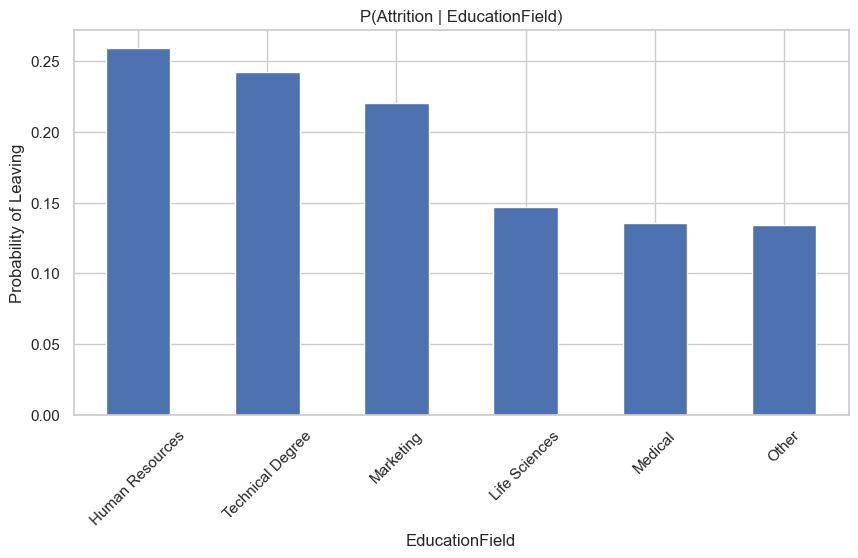

In [ ]:
cat_col = 'EducationField'

cat_df = df.groupby(cat_col)['Attrition'].mean().sort_values(ascending=False)

cat_df.plot(kind='bar', figsize=(10,5))
plt.title(f'P(Attrition | {cat_col})')
plt.ylabel('Probability of Leaving')
plt.xticks(rotation=45)
plt.show()

## 3.7 Interaction & Advanced Analysis

In this section, we explore interactions between multiple features to better understand complex patterns behind employee attrition.

These analyses go beyond single-variable relationships and help identify:
- Combined effects of compensation and seniority  
- Interaction between role, workload, and structure  
- Feature importance through impact comparisons  

### Interaction: Compensation & Seniority

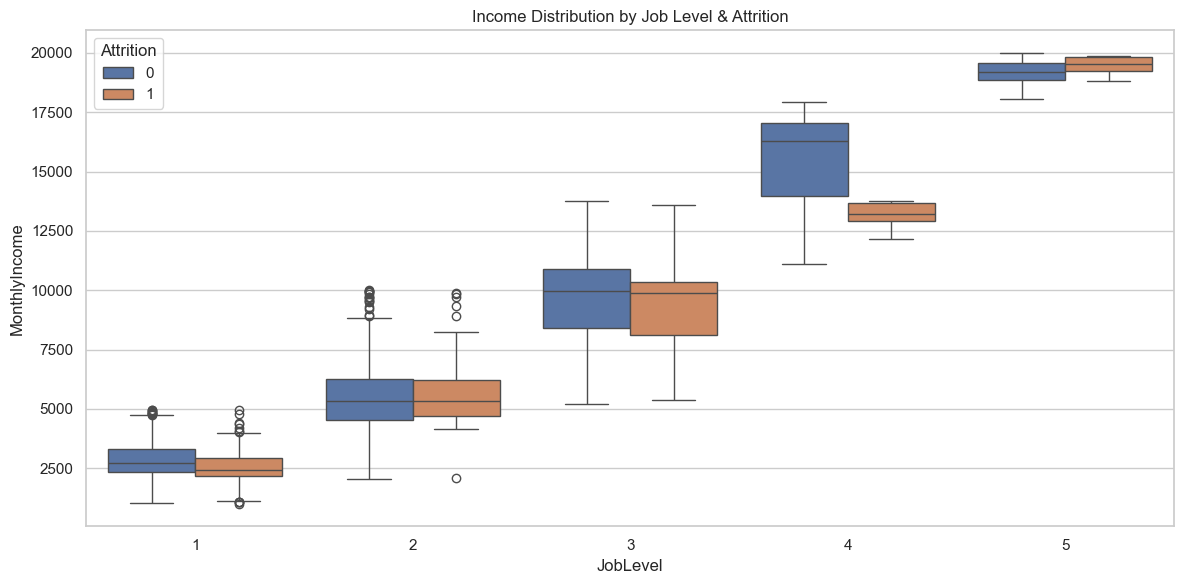

<Figure size 640x480 with 0 Axes>

In [248]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))



sns.boxplot(
    data=df,
    x='JobLevel',
    y='MonthlyIncome',
    hue='Attrition'
)

plt.title('Income Distribution by Job Level & Attrition')
plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

/var/folders/44/bgk7f8f14ts6lstf71mlfw7w0000gn/T/ipykernel_37341/1591524663.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = df.groupby(['incomeBin', 'JobLevel'])['Attrition'].mean().unstack()


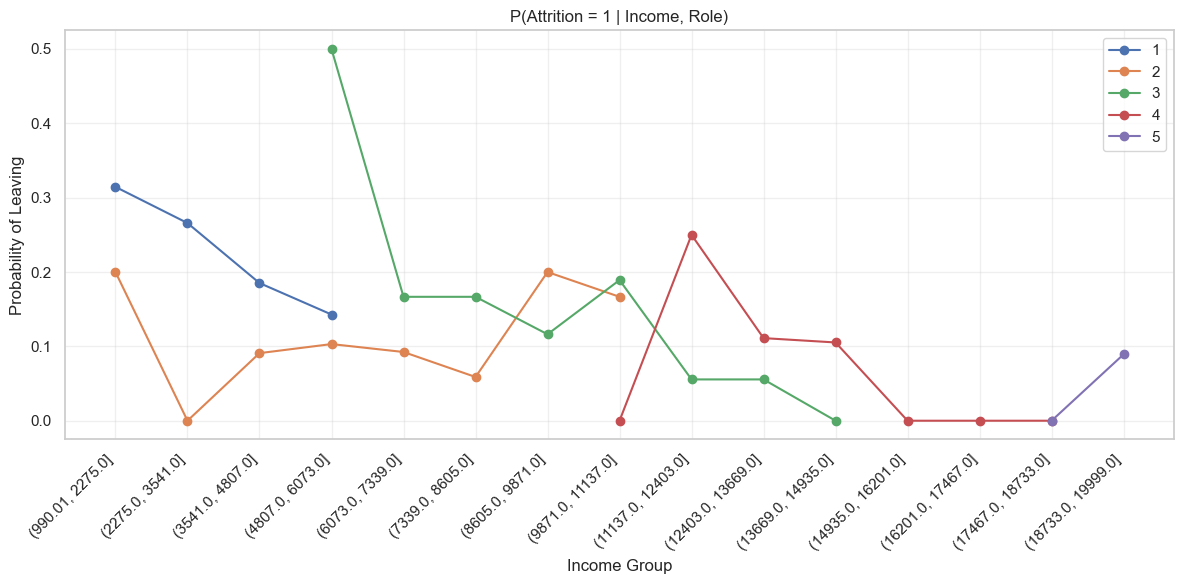

In [ ]:
df['incomeBin'] = pd.cut(df['MonthlyIncome'], bins=15)

result = df.groupby(['incomeBin', 'JobLevel'])['Attrition'].mean().unstack()

plt.figure(figsize=(12,6))

for col in result.columns:
    plt.plot(result.index.astype(str), result[col], marker='o', label=col)

plt.title('P(Attrition = 1 | Income, Role)')
plt.xlabel('Income Group')
plt.ylabel('Probability of Leaving')

plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Interaction: Life Stage & Experience

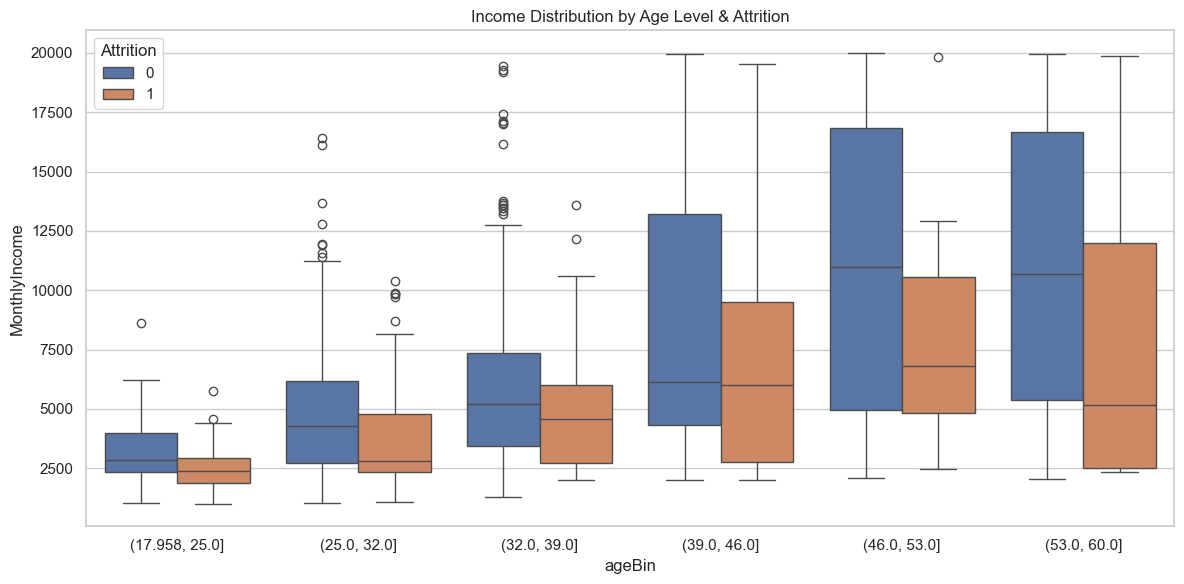

<Figure size 640x480 with 0 Axes>

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))



sns.boxplot(
    data=df,
    x='ageBin',
    y='MonthlyIncome',
    hue='Attrition'
)

plt.title('Income Distribution by Age Level & Attrition')
plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

### Interaction: Role Structure & Workload

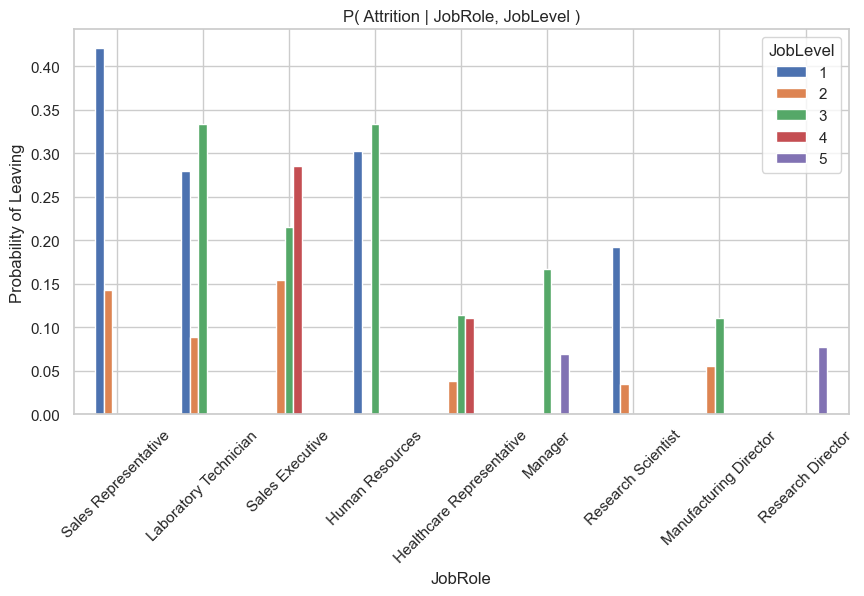

In [ ]:
pivot  = df.groupby(['JobRole','JobLevel'])['Attrition'].mean().sort_values(ascending=False).unstack()

pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]
pivot.plot(kind='bar', figsize=(10,5))
plt.title('P( Attrition | JobRole, JobLevel )')
plt.ylabel('Probability of Leaving')
plt.xticks(rotation=45)
plt.show()

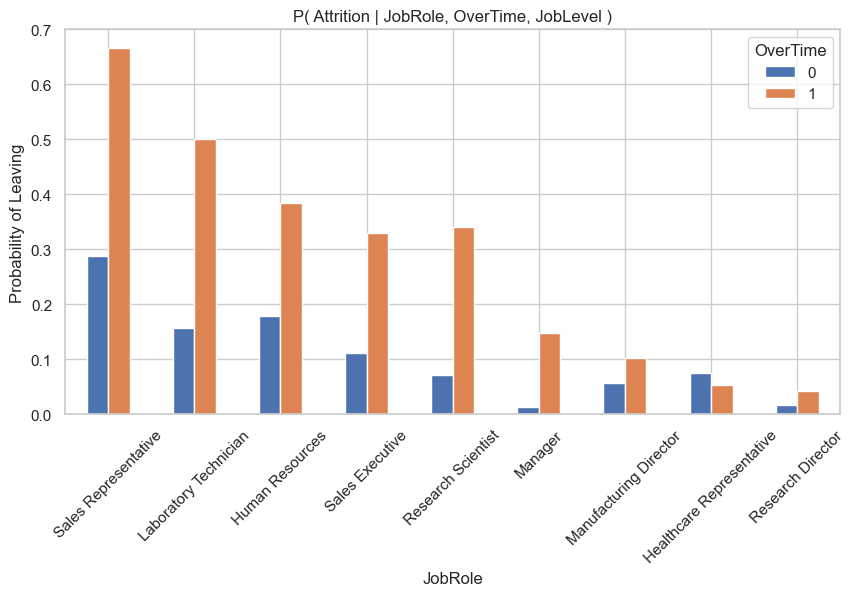

In [ ]:
pivot  = df.groupby(['JobRole','OverTime'])['Attrition'].mean().sort_values(ascending=False).unstack()
pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]
pivot.plot(kind='bar', figsize=(10,5))
plt.title('P( Attrition | JobRole, OverTime )')
plt.ylabel('Probability of Leaving')
plt.xticks(rotation=45)
plt.show()

### Feature Impact Analysis

In [254]:
# P(Attrition = 1 | feature = value)
binary_features = [
    col for col in df.columns
    if df[col].dropna().isin([0,1]).all() and col != 'Attrition'
]

final_df = (
    df[binary_features + ['Attrition']]
    .melt(id_vars='Attrition', var_name='feature', value_name='value')
    .groupby(['feature', 'value'])['Attrition']
    .mean()
    .unstack()  
)


final_df.columns = ['P_leave_0', 'P_leave_1']  
final_df['p1_greater'] = final_df['P_leave_1'] > final_df['P_leave_0']
final_df

,P_leave_0,P_leave_1,p1_greater
feature,,,
BusinessTravel_Travel_Frequently,0.140821,0.249097,True
BusinessTravel_Travel_Rarely,0.189696,0.149569,False
Department_Research & Development,0.204322,0.138398,False
Department_Sales,0.141602,0.206278,True
EducationField_Life Sciences,0.171296,0.146865,False
EducationField_Marketing,0.154081,0.220126,True
EducationField_Medical,0.172962,0.135776,False
EducationField_Other,0.162824,0.134146,False
EducationField_Technical Degree,0.153214,0.242424,True


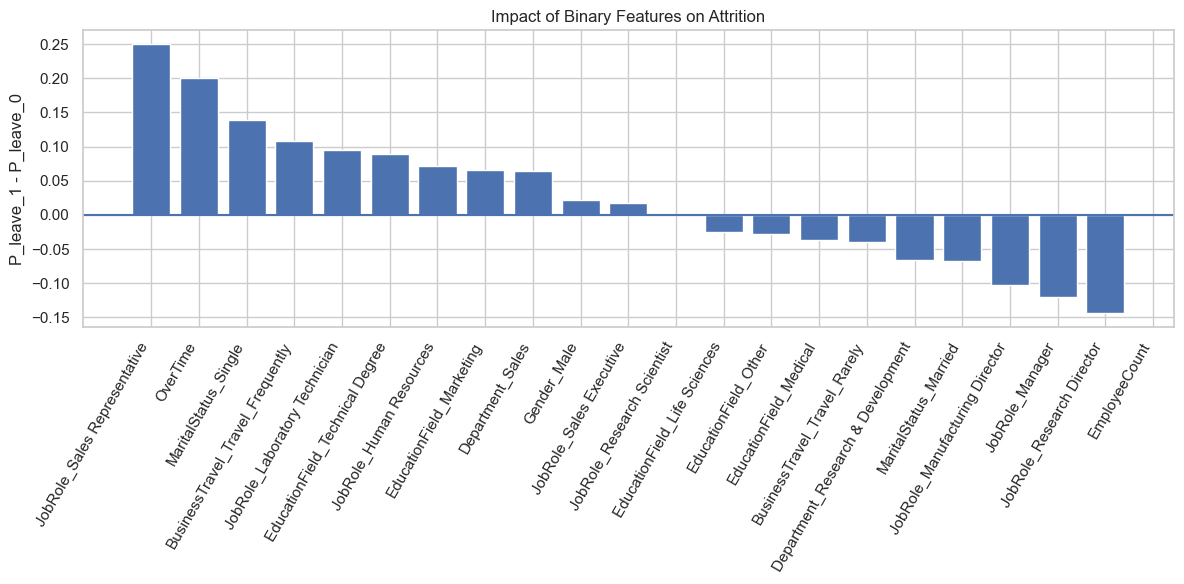

In [255]:
import matplotlib.pyplot as plt

# sort by impact
plot_df = final_df.copy()
plot_df['diff'] = plot_df['P_leave_1'] - plot_df['P_leave_0']
plot_df = plot_df.sort_values('diff', ascending=False)

plt.figure(figsize=(12,6))

plt.bar(plot_df.index, plot_df['diff'])

plt.axhline(0)  # baseline
plt.title('Impact of Binary Features on Attrition')
plt.ylabel('P_leave_1 - P_leave_0')
plt.xticks(rotation=60, ha='right')

plt.tight_layout()
plt.show()